# Redes de Jackson

In [1]:
#using Pkg;Pkg.instantiate(); Pkg.update()

## Motivación

En muchas aplicaciones los clientes no son atendidos por un único servidor sino que recorren una secuencia de etapas:

* Un paquete de datos atraviesa varios routers en Internet.
* Un trabajo de manufactura pasa por varias máquinas en una fábrica.
* Una transacción web pasa por ejemplo por un balanceador, un servidor de aplicación y consultas a una base de datos.

La pregunta natural es: ¿podemos analizar el comportamiento en estado estacionario de toda la red?,

**Problema:** el estado del sistema tiene que tener en cuenta la ocupación de cada uno de los subsistemas presentes.

¿Cómo hacemos para resolver esta Cadena de Markov de alta dimensión?


## Modelo

Una **Red de Jackson abierta** con $J$ nodos consiste en:

 * En cada nodo $j = 1,\ldots,J$ hay **un servidor** con tiempos de servicio exponenciales de tasa $\mu_j$, disciplina FIFO.
 * Llegan clientes externos al nodo $j$ según un proceso de Poisson de tasa $\nu_j \geqslant 0$. Se asume que al menos un nodo recibe clientes externos.
 * Cuando un cliente termina de ser atendido en el nodo $j$, se dirige al nodo $k$ con probabilidad $r_{jk}$, o abandona la red ("sale") con probabilidad $d_j = 1 - \sum_{k=1}^J r_{jk} \geqslant 0$.
 * Todos los tiempos de arribo y servicio son *independientes*. En particular, al cambiar de servidor se sortea nuevamente el tiempo de servicio.


### Matriz de Ruteo

Las probabilidades $r_{jk}$ forman la **matriz de ruteo**:

$$R = (r_{jk})_{J \times J}$$

con $r_{jk} \geqslant 0$ y $\sum_k r_{jk} \leqslant 1$ para todo $j$.

**Observación:** no necesariamente todos los nodos $j$ tienen salidas.

### Ejemplo

![jackson net](../images/jackson.png)

### Estado del sistema

El **estado** del sistema en el instante $t$ es el vector:

$$\mathbf{n}(t) = (n_1(t), \ldots, n_J(t)) \in \mathbb{N}^J,$$

donde $n_j(t)$ es el número de clientes en el nodo $j$ (en cola más en servicio). Este es una cadena de Markov de tiempo continuo.

### Tasas de transición

Sea $\mathbf{e}_j$ el vector que tiene solamente un $1$ en la coordenada $j$ (vector canónico). Entonces las tasas de transición de la cadena son:

\begin{align*}
\text{Arribos nuevos a una cola:}\quad & \mathbf{n} \mapsto \mathbf{n}+\mathbf{e}_i& \nu_i\\
\\
\text{Transición de una tarea entre colas:}\quad & \mathbf{n} \mapsto \mathbf{n}-\mathbf{e}_i + \mathbf{e}_j & \mu_i r_{ij} \mathbf{1}_{\{n_i>0\}}\\
\\
\text{Partidas definitivas una cola:}\quad & \mathbf{n} \mapsto \mathbf{n}-\mathbf{e}_i & \mu_i \mathbf{1}_{\{n_i>0\}}
\end{align*}

#### Ejemplo: cola en tándem

Consideremos una cola $M/M/1$ cuya salida alimenta a otra, es decir:

![tandem](../images/tandem_queue.png)

En este caso el estado es $\mathbf{n} = (n_1,n_2)$ y las tres transiciones son:

$$\begin{cases} \mathbf{n} \mapsto \mathbf{n} + (1,0) & \nu \\
\mathbf{n} \mapsto \mathbf{n} + (-1,1) & \mu_1 \mathbf{1}_{\{n_1>0\}} \\
\mathbf{n} \mapsto \mathbf{n} + (1,0) & \mu_2 \mathbf{1}_{\{n_2>0\}}
\end{cases}$$

Podemos verla como una red de Jackson simple con:

  * $J=2$ nodos.
  * Tasa de arribos exógena $\boldsymbol{\nu} = (\nu,0)$.
  * Matriz de ruteo 
  $$R=\begin{pmatrix}0 & 1 \\ 0 & 0\end{pmatrix},$$
  * Tasas de serivcio $\boldsymbol{\mu} = (\mu_1,\mu_2)$.

## Ecuaciones de tráfico

Sea $\lambda_j$ a la **tasa total de llegadas** al nodo $j$: la suma de las llegadas externas más las que provienen de otros nodos.

* Si el sistema llega a régimen, la tasa de salida de la cola $j$ deberá ser igual a su tasa de entrada $\lambda_j$.
* Por lo tanto, la tasa de tráfico de $i\to j$ es $\lambda_i r_{ij}$.

Esto permite definir las ecuaciones de tráfico:
$$\lambda_j = \nu_j + \sum_{i=1}^{J} \lambda_i \, r_{ij}, \quad j = 1, \ldots, J$$

En forma matricial, definiendo $\boldsymbol{\lambda} = (\lambda_1,\ldots,\lambda_J)^T$ y $\boldsymbol{\nu} = (\nu_1,\ldots,\nu_J)^T$:

$$\boldsymbol{\lambda} = \boldsymbol{\nu} + R^T \boldsymbol{\lambda} \implies (I - R^T)\boldsymbol{\lambda} = \boldsymbol{\nu}$$

### Cadena auxiliar

Dada una red de Jackson $(\boldsymbol{\nu},\boldsymbol{\mu},R)$, sea $Y_n$ la cadena de Markov de tiempo discreto con estados $E=\{0,1,\ldots,J\}$ y matriz de transiciones:

$$P=\begin{pmatrix} 0 & \nu_1/\nu & \cdots & \nu_j/\nu \\
                    d_1 & r_{11} & \cdots & r_{1J} \\
                    \vdots & \vdots & \ddots & \vdots \\
                    d_J & r_{J1} & \cdots & r_{JJ} \end{pmatrix}$$
                    
con $\nu = \sum_i \nu_i$ la tasa total de arribo a la red.

**Observación:** la matriz anterior define una CMTD. Suma $1$ por filas por construcción.

**Interpretación:** las trayectorias de $Y$ son las que siguen las tareas por la red:

  * $0$ es estar "afuera".
  * Entra por el nodo $j$ con probabilidad $\nu_j/\nu$.
  * Recorre la red según $R$.
  * Vuelve al estado $0$ desde el estado $j$ con probabilidad $d_j$ (sale de la red).

### Irreducibilidad

**Lema:** la cadena $\mathbf{n}(t)$ es irreducible si y solo si la cadena $Y_n$ (o su matriz $P$) es irreducible.

Esto ocurre si:

   * Desde afuera de la red puedo llegar a cualquier nodo.
   * Desde cualquier nodo existe un camino que me lleva al estado $0$. Es decir, existe un camino con probabilidad positiva de salir de la red.

#### Ejemplo:

Para la red:

![feedback counterexample](../images/feedback_queue_counterexample.png)

La matriz $P$ queda:

$$P = \begin{pmatrix} 0 & \nu & 0 \\
                      0 & 0 & 1 \\
                      0 & 1 & 0 \end{pmatrix}$$
                      
$P$ no es irreducible (no se puede volver al estado $0$, o sea, no se puede salir de la red). 

En el sistema original, los trabajos que ingresan quedan cambiando entre la cola $1$ y $2$ para siempre sin salir $\Rightarrow$ no puede haber equilibrio.

### Solución de la ecuación de tráfico:


**Proposición.** Si la red es irreducible, el sistema $(I - R^T)\boldsymbol{\lambda} = \boldsymbol{\nu}$ tiene solución única y positiva.

**Demostración.** Si la red es irreducible, la matriz $P$ define una CMTD irreducible. Por lo tanto, existe una única distribución de probabilidad $\pi$ que cumple:

$$\pi = \pi P$$

y además todos sus términos son positivos. Escribiendo cada término de los anteriores:

\begin{align*}
\pi_0 &= \sum_{i=1}^J \pi_i d_i\\
\pi_j &= \pi_0 \frac{\nu_i}{\nu} + \sum_{i=1}^J \pi_i r_{ij} \quad j=1,\ldots,N\end{align*}

Nos quedamos con el segundo conjunto de ecuaciones y definimos $\lambda_i = \frac{\nu}{\pi_0} \pi_i$. Multiplicando por $\nu$ y dividiendo entre $\pi_0>0$ en la ecuación de balance queda:

$$\lambda_j = \nu_j + \sum_{i=1}^{J} \lambda_i \, r_{ij}, \quad j = 1, \ldots, J$$

que es la ecuación de tráfico que queríamos resolver.

## Teorema de Jackson

**Teorema (Jackson, 1957).** Sea una red de Jackson abierta con $J$ nodos M/M/1. Sea $\boldsymbol{\lambda}$ la solución de las ecuaciones de tráfico y supongamos que $\rho_j = \lambda_j/\mu_j < 1$ para todo $j$. Entonces la cadena de Markov $(\mathbf{n}(t))$ es ergódica y su distribución estacionaria tiene **forma producto**:

$$\pi(\mathbf{n}) = \pi(n_1, \ldots, n_J) = \prod_{j=1}^{J} (1-\rho_j)\rho_j^{n_j}$$

Es decir, en estado estacionario los nodos se comportan como $J$ colas **M/M/1 independientes**, con la cola $j$ teniendo distribución geométrica de parámetro $\rho_j$.

### Demostración:

Debemos verificar que $\pi(\mathbf{n}) = \prod_j (1-\rho_j)\rho_j^{n_j}$ satisface las **ecuaciones de balance global**: para todo estado $\mathbf{n}$,

$$\pi(\mathbf{n}) \sum_{\mathbf{m} \neq \mathbf{n}} q(\mathbf{n},\mathbf{m}) = \sum_{\mathbf{m} \neq \mathbf{n}} \pi(\mathbf{m})q(\mathbf{m},\mathbf{n})$$

donde $q(\mathbf{n},\mathbf{m})$ son las tasas de transición de la cadena. 

Identificamos todos los tipos de transición posibles desde/hacia $\mathbf{n}$:

**Transiciones que salen de $\mathbf{n}$** (lado izquierdo):
- Llegada externa al nodo $i$: tasa $\nu_j$, lleva a $\mathbf{n} + \mathbf{e}_i$.
- Servicio en nodo $i$ con ruteo a nodo $j$ ($j \neq i$): tasa $\mu_i r_{ij} \mathbf{1}_{n_i > 0}$, lleva a $\mathbf{n} - \mathbf{e}_i + \mathbf{e}_j$.
- Servicio en nodo $i$ con salida de la red: tasa $\mu_i d_i \mathbf{1}_{n_i > 0}$, lleva a $\mathbf{n} - \mathbf{e}_i$.

Combinando lo anterior, la tasa total de salida de $\mathbf{n}$ es:
$$\sum_{\mathbf{m}\neq \mathbf{n}} q(\mathbf{n},\mathbf{m}) = \sum_i \nu_i + \sum_i \mu_i \sum_{j\neq i} r_{ij} \mathbf{1}_{n_i>0} + \sum_i \mu_i d_i \mathbf{1}_{n_i>0} = \sum_i \nu_i + \sum_i \mu_i (1-r_{ii}) \mathbf{1}_{n_i>0}$$

Y el lado izquierdo queda:
$$\pi(\mathbf{n}) \left[\sum_i \nu_i + \sum_i \mu_i (1-r_{ii})\mathbf{1}_{n_i>0}\right]$$

**Transiciones que entran a $\mathbf{n}$** (lado derecho):

- Desde $\mathbf{n} - \mathbf{e}_i$ (llegada externa a $i$): tasa $\nu_i$, contribuye $\nu_i \pi(\mathbf{n}-\mathbf{e}_i)$ si $n_i>0$ (si no no se puede llegar por debajo).
- Desde $\mathbf{n} + \mathbf{e}_j - \mathbf{e}_i$ (servicio en $j$, ruteo a $i$, $j\neq i$): tasa $\mu_j r_{ji}$, contribuye $\mu_j r_{ji} \pi(\mathbf{n}+\mathbf{e}_j-\mathbf{e}_i)$ siempre que $n_j>0$.
- Desde $\mathbf{n} + \mathbf{e}_i$ (servicio en $i$, sale de la red): tasa $\mu_i d_i$, contribuye $\mu_i d_i \pi(\mathbf{n}+\mathbf{e}_i)$.

Por lo tanto el lado derecho queda sumando todas las posibilidades y en todos los sitios $i$:

$$\sum_i \left[\nu_i \pi(\mathbf{n} - \mathbf{e}_i) \mathbf{1}_{n_i>0} + \sum_{j\neq i} \mu_j r_{ji} \pi(\mathbf{n}+\mathbf{e}_j-\mathbf{e}_i)\mathbf{1}_{n_j>0} + \mu_i d_i \pi(\mathbf{n}+\mathbf{e}_i)\right].$$

Dividiendo entre $\pi(\mathbf{n})$ que supusimos positivo, la ecuación queda:

$$\sum_i \nu_i + \sum_i \mu_i (1-r_{ii})\mathbf{1}_{n_i>0} = \sum_i \left[ \nu_i \frac{\pi(\mathbf{n} - \mathbf{e}_i)}{\pi(\mathbf{n})}\mathbf{1}_{n_i>0} + \sum_{j\neq i} \mu_j r_{ji} \frac{\pi(\mathbf{n}-\mathbf{e}_j+\mathbf{e}_i)}{\pi(\mathbf{n})}\mathbf{1}_{n_i>0} + \mu_i d_i \frac{\pi(\mathbf{n}+\mathbf{e}_i)}{\pi(\mathbf{n})}\right]. \tag{*}$$

Calculamos entonces los cocientes entre $\pi$ en estados vecinos, para la distribución producto propuesta: $\pi(\mathbf{n}) = \prod_{j=1}^{J} (1-\rho_j)\rho_j^{n_j}$.

\begin{align*}
\frac{\pi(\mathbf{n}-\mathbf{e}_i)}{\pi(\mathbf{n})} &= \frac{\rho_i^{n_i-1}}{\rho_i^{n_i}} = \frac{1}{\rho_i} & (n_i>0)\\
\frac{\pi(\mathbf{n}+\mathbf{e}_j-\mathbf{e}_i)}{\pi(\mathbf{n})} &= \frac{\rho_j}{\rho_i} & (n_i > 0) \\
\frac{\pi(\mathbf{n}+\mathbf{e}_i)}{\pi(\mathbf{n})} &= \frac{\rho_i^{n_i+1}}{\rho_i^{n_i}} = \rho_i.
\end{align*}

Sustituimos en el lado derecho de (*)

$$ \sum_i \left[ \nu_i \frac{1}{\rho_i}\mathbf{1}_{n_i>0} + \sum_{j\neq i} \mu_j r_{ji} \frac{\rho_j}{\rho_i}\mathbf{1}_{n_i>0} + \mu_i d_i \rho_i\right] =  \sum_i \left[ \nu_i \frac{\mu_i}{\lambda_i}\mathbf{1}_{n_i>0} + \sum_{j\neq i} \mu_j r_{ji} \frac{\lambda_j \mu_i}{\lambda_i \mu_j}\mathbf{1}_{n_i>0} + \mu_i d_i \frac{\lambda_i}{\mu_i}\right].$$

Simplificando:

$$\sum_i \left[\nu_i \frac{\mu_i}{\lambda_i}\mathbf{1}_{n_i>0} + \sum_{j\neq i} r_{ji} \frac{\lambda_j \mu_i}{\lambda_i}\mathbf{1}_{n_i>0} + d_i\lambda_i\right].$$

Reagrupando y usando las ecuaciones de tráfico $\lambda_i = \nu_i + \sum_j \lambda_j r_{ji}$ obtenemos::

$$\sum_i \frac{\mu_i}{\lambda_i}\mathbf{1}_{n_i>0}  \underbrace{\left[\nu_i + \sum_{j\neq i} \lambda_j r_{ji} \right]}_{\lambda_i(1-r_{ii})} + \sum_i d_i\lambda_i.$$

Que se simplifica a:

$$\sum_i \mu_i (1-r_{ii})\mathbf{1}_{n_i>0} + \sum_i d_i \lambda_i$$

Por lo tanto la ecuación a probar es:

$$\sum_i \nu_i + \sum_i \mu_i (1-r_{ii})\mathbf{1}_{n_i>0} = \sum_i \mu_i (1-r_{ii})\mathbf{1}_{n_i>0} + \sum_i d_i \lambda_i$$

Queda ver entonces que $\sum_i \nu_i = \sum_i d_i \lambda_i$, es decir, la tasa total de entrada a la red es igual a la tasa total de partida. Pero si tomamos las ecuaciones de tráfico:

$$\lambda_i = \nu_i + \sum_j \lambda_j r_{ji} \qquad i=1,\ldots,J$$

Sumando todas las ecuaciones nos queda:

\begin{align*}
\sum_i \lambda_i &= \sum_i \nu_i + \sum_i \sum_j \lambda_j r_{ji}\\
&= \sum_i \nu_i + \sum_j \lambda_j \underbrace{\sum_i r_{ji}}_{1-d_i}
\end{align*}

De donde cancelando se obtiene la igualdad deseada.

### ¿Por qué funciona? Teorema de Burke

La prueba revela que la clave es que las ecuaciones de tráfico son **exactamente lo que se necesita** para que el balance global se cumpla. Esto no es casualidad: en el fondo, el teorema funciona porque la salida de cada cola M/M/1 en estado estacionario es un proceso de Poisson (Teorema de Burke), lo que hace que cada nodo "vea" llegadas Poisson independientemente de lo que ocurre en el resto de la red.

### Métricas de performance

Por el teorema, cada nodo $j$ es una cola M/M/1 con tasa de llegadas $\lambda_j$ y tasa de servicio $\mu_j$. Las fórmulas son las ya conocidas:

* Utilización del nodo $j$: $\rho_j = \lambda_j/\mu_j$
* Clientes medios en nodo $j$: $\bar{X}_j = \rho_j/(1-\rho_j)$
* Tiempo medio en cada visita a $j$: $W_j = 1/(\mu_j - \lambda_j)$

Para la red completa, por la ley de Little aplicada globalmente:

$$\bar{X} = \sum_{j=1}^J \bar{X}_j, \qquad W = \frac{\bar{X}}{\Lambda}$$

donde $\Lambda = \sum_j \nu_j$ es la tasa total de llegadas externas a la red.

## Ejemplos numéricos

In [2]:
using LinearAlgebra, Distributions, Plots, Printf, LaTeXStrings

In [3]:
"""Funcion que resuelve las ecuaciones de tráfico λ = ν + Rᵀλ."""
function trafico_jackson(ν, R)
    J = length(ν)
    A = Matrix(I, J, J) - R'   # (I - Rᵀ)
    return A \ ν
end

trafico_jackson

In [4]:
"""Analiza una red de Jackson (nodos M/M/1) y reporta métricas."""
function analizar_red_jackson(ν, μ, R ; output=true)
    J = length(ν)
    λ = trafico_jackson(ν, R)
    ρ = λ./μ
    all(ρ .< 1) || error("Red inestable: ρ = $(round.(ρ, digits=3))")

    X  = ρ./(1.0.-ρ)
    Q = (ρ.^2)./(1.0.-ρ)
    W  = 1.0./(μ-λ)
    V = ρ./(μ-λ)
    Λ = sum(ν)
    Xtot = sum(X)
    Wtot = Xtot / Λ
    
    if(output)
        println("=" ^ 65)
        println("ANÁLISIS DE RED DE JACKSON (nodos M/M/1)")
        println("=" ^ 65)
        println()
        println("Tasas de llegada totales por nodo:")
        for j in 1:J
            @printf "  Nodo %d: λ = %.4f  (externa: %.4f, interna: %.4f)\n" j λ[j] ν[j] (λ[j]-ν[j])
        end
        println()
        header = @sprintf "%-6s %-8s %-8s %-8s %-10s %-10s %-10s %-10s" "Nodo" "λ" "μ" "ρ" "X" "Q" "W" "V"
        println(header)
        println("-" ^ 72)
        for j in 1:J
            row = @sprintf "%-6d %-8.4f %-8.4f %-8.4f %-10.4f %-10.4f %-10.4f %-10.4f" j λ[j] μ[j] ρ[j] X[j] Q[j] W[j] V[j]
            println(row)
        end
        
        println()
        println("Métricas globales de la red:")
        @printf "  Tasa total de entradas\tΛ = %.4f\n" Λ
        @printf "  Ocupación media de la red\tX = %.4f\n" Xtot
        @printf "  Retardo medio en la red\tW = %.4f\n" Wtot
        println()
    end
    
    return (λ=λ, ρ=ρ, X=X, Q=Q, W=W, V=V, Xtot=Xtot, Wtot=Wtot)
end

analizar_red_jackson

### Ejemplo 1: Red en tándem

El caso más simple de red de Jackson: dos colas en serie. Todos los clientes pasan por el nodo 1 y luego por el nodo 2, modelando por ejemplo una arquitectura web con un proxy y un servidor de aplicación.

![tandem](../images/tandem_queue.png)

Las ecuaciones de tráfico aquí son triviales, ya que solo se ingresa por el nodo $1$ y todo pasa al nodo $2$:
\begin{align*}
\lambda_1 &= \nu \\
\lambda_2 &= \lambda_1.
\end{align*}

Por lo tanto el sistema tiene cargas $\rho_1=\frac{\nu}{\mu_1}$ y $\rho_2=\frac{\nu}{\mu_2}$. La menor de ellas opera como **cuello de botella**.

Hagamos un ejemplo:

**Parámetros:** $\nu = 3$, $\mu_1 = 5$, $\mu_2 = 4$ por lo que $\rho_1=0.6$ y $\rho_2=0.75$.

El tiempo medio total en la red es:

$$W = W_1 + W_2 = \frac{1}{\mu_1 - \lambda} + \frac{1}{\mu_2 - \lambda} = \frac{1}{2} + 1 = 1.5$$

Verificamos que coincide con la ley de Little global:

$$\bar{X} = \frac{.6}{1-.6} + \frac{.75}{1-.75} = 4.5 \Rightarrow W = \frac{4.5}{3} = 1.5$$ 

In [5]:
ν1 = [3.0, 0.0]
μ1     = [5.0, 4.0]
R1     = [0.0  1.0
          0.0  0.0]

res1 = analizar_red_jackson(ν1, μ1, R1);

ANÁLISIS DE RED DE JACKSON (nodos M/M/1)

Tasas de llegada totales por nodo:
  Nodo 1: λ = 3.0000  (externa: 3.0000, interna: 0.0000)
  Nodo 2: λ = 3.0000  (externa: 0.0000, interna: 3.0000)

Nodo   λ        μ        ρ        X          Q          W          V         
------------------------------------------------------------------------
1      3.0000   5.0000   0.6000   1.5000     0.9000     0.5000     0.3000    
2      3.0000   4.0000   0.7500   3.0000     2.2500     1.0000     0.7500    

Métricas globales de la red:
  Tasa total de entradas	Λ = 3.0000
  Ocupación media de la red	X = 4.5000
  Retardo medio en la red	W = 1.5000



### Ejemplo 2: Red con retroalimentación

Este modelo es similar al anterior, pero con una probabiliodad $p$ de que la tarea falle en el nodo $1$ y deba ser reprocesada, antes de pasar a $2$.

![tandem_queue_feedback](../images/tandem_queue_feedback.png)

Ecuaciones de tráfico:

\begin{equation*}
\begin{cases}
\lambda_1 = \nu + p \lambda_1 \\
\lambda_2 = (1-p)\lambda_1 \\
\end{cases} \Longrightarrow \lambda_1 = \frac{\nu}{1-p}, \quad \lambda_2 = \nu
\end{equation*}

La realimentación afecta la carga del nodo $1$ debido a los reintentos. El nodo $2$ no se ve afectado ya que eventualmente todo el tráfico de $1$ termina en él.

Ejemplo:

**Parámetros:** $\nu = 3$, $\mu_1 = 5$, $\mu_2 = 4$, $p = 0.25$.

In [6]:
p = 0.25
ν = [3.0, 0.0]
μ     = [5.0, 4.0]
R     = [p    (1-p)
          0.0   0.0 ]

res = analizar_red_jackson(ν, μ, R);

ANÁLISIS DE RED DE JACKSON (nodos M/M/1)

Tasas de llegada totales por nodo:
  Nodo 1: λ = 4.0000  (externa: 3.0000, interna: 1.0000)
  Nodo 2: λ = 3.0000  (externa: 0.0000, interna: 3.0000)

Nodo   λ        μ        ρ        X          Q          W          V         
------------------------------------------------------------------------
1      4.0000   5.0000   0.8000   4.0000     3.2000     1.0000     0.8000    
2      3.0000   4.0000   0.7500   3.0000     2.2500     1.0000     0.7500    

Métricas globales de la red:
  Tasa total de entradas	Λ = 3.0000
  Ocupación media de la red	X = 7.0000
  Retardo medio en la red	W = 2.3333



### Ejemplo 3: Red de tres nodos con ruteo probabilístico

Una red que modela un sistema de procesamiento de transacciones con tres etapas. Los clientes entran por el nodo 1 (autenticación), luego van al nodo 2 (procesamiento) con probabilidad 0.6 o al nodo 3 (caché) con probabilidad 0.4. Desde el nodo 2, el 30% de los casos requieren consultar el nodo 3 antes de salir.

![jackson3queues](../images/jackson_3_queues.png)

Matriz de ruteo:
$$R = \begin{pmatrix} 0 & 0.6 & 0.4 \\ 0 & 0 & 0.3 \\ 0 & 0 & 0 \end{pmatrix}$$

A modo de ejemplo, construyamos la matriz de visitas $P$:
$$R = \begin{pmatrix} 0 & 1 & 0 & 0 \\ 0 & 0 & 0.6 & 0.4 \\ 0.7 & 0 & 0 & 0.3 \\ 1 & 0 & 0 & 0 \end{pmatrix}$$


Las ecuaciones de tráfico son:
\begin{equation*}
\begin{cases}
\lambda_1 = \nu \\ \\
\lambda_2 = 0.6\lambda_1 \\ \\
\lambda_3 = 0.4\lambda_1 + 0.3\lambda_2
\end{cases}
\end{equation*}

Ejemplo $\nu=5$, $\mu_1=8$, $\mu_2=6$, $\mu_3=10$.

In [7]:
ν = [7.5, 0.0, 0.0]
μ     = [8.0, 6.0, 10.0]
R     = [0.0  0.6  0.4
          0.0  0.0  0.3
          0.0  0.0  0.0]

res = analizar_red_jackson(ν, μ, R);

ANÁLISIS DE RED DE JACKSON (nodos M/M/1)

Tasas de llegada totales por nodo:
  Nodo 1: λ = 7.5000  (externa: 7.5000, interna: 0.0000)
  Nodo 2: λ = 4.5000  (externa: 0.0000, interna: 4.5000)
  Nodo 3: λ = 4.3500  (externa: 0.0000, interna: 4.3500)

Nodo   λ        μ        ρ        X          Q          W          V         
------------------------------------------------------------------------
1      7.5000   8.0000   0.9375   15.0000    14.0625    2.0000     1.8750    
2      4.5000   6.0000   0.7500   3.0000     2.2500     0.6667     0.5000    
3      4.3500   10.0000  0.4350   0.7699     0.3349     0.1770     0.0770    

Métricas globales de la red:
  Tasa total de entradas	Λ = 7.5000
  Ocupación media de la red	X = 18.7699
  Retardo medio en la red	W = 2.5027



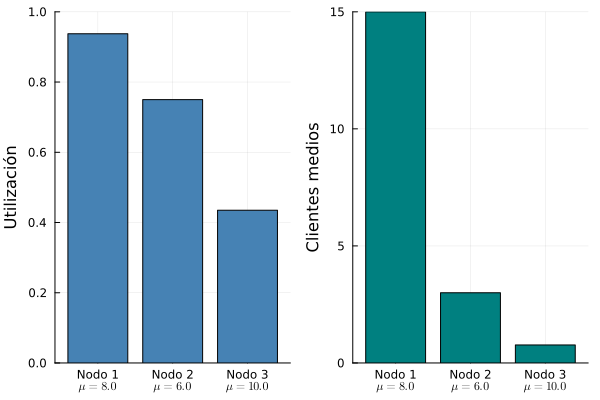

In [8]:
# Visualización: utilización y clientes medios por nodo
nodos = ["Nodo 1\n"*L"\mu=%$(μ[1])", "Nodo 2\n"*L"\mu=%$(μ[2])", "Nodo 3\n"*L"\mu=%$(μ[3])"]

p1 = bar(nodos, res.ρ, ylabel="Utilización", color=:steelblue, legend=false, ylims=(0,1))
p2 = bar(nodos, res.X, ylabel="Clientes medios", color=:teal, legend=false)

plot(p1, p2, layout=(1,2))

### Análisis del cuello de botella

En el ejemplo anterior, es claro que el punto de entrada opera como **cuello de botella**. Observar que en este caso no es el nodo más lento, sino el más cargado. El caché en el caso anterior cumple la función de descargar al nodo lento, por lo que el cuello de botella pasa a ser el nodo de entrada.

**Obsevación:** Cuando la tasa de llegadas se acerca a la capacidad del cuello de botella, el tiempo de espera en ese nodo domina el tiempo total en la red

Analizamos cómo varía $W$ al variar la tasa de llegadas del ejemplo anterior. Observar que para estabilidad se requiere:

\begin{align*}
\lambda_1 < \mu_1 & \Rightarrow \nu < 8 \\ \\
\lambda_2 < \mu_2 & \Rightarrow 0.6 \nu < 6 \Rightarrow \nu<10 \\ \\
\lambda_3 < \mu_3 & \Rightarrow (0.4) \nu + (0.3)(0.6) \nu < 10 \Rightarrow \nu < 17.24
\end{align*}

de donde queda claro que $\nu<8$ es la condición más restrictiva.

In [9]:
ν_range = 4.0:0.1:7.9
μ     = [8.0, 6.0, 10.0]
R     = [0.0  0.6  0.4
          0.0  0.0  0.3
          0.0  0.0  0.0]

W_red  = Float64[]
W_n1   = Float64[]
W_n2   = Float64[]
W_n3   = Float64[]

for ν in ν_range
    res = analizar_red_jackson([ν, 0.0, 0.0], μ, R ; output=false)
    push!(W_red, res.Wtot)
    push!(W_n1,  res.W[1])
    push!(W_n2,  res.W[2])
    push!(W_n3,  res.W[3])
end

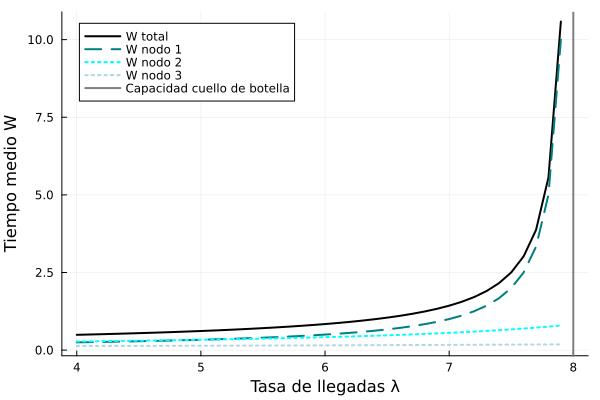

In [10]:
plot(ν_range, W_red, label="W total", lw=2, color=:black)
plot!(ν_range, W_n1, label="W nodo 1", lw=2, color=:teal, linestyle=:dash)
plot!(ν_range, W_n2, label="W nodo 2", lw=2, color=:cyan, linestyle=:dot)
plot!(ν_range, W_n3, label="W nodo 3", lw=2, color=:lightblue, linestyle=:dot)

vline!([8], label="Capacidad cuello de botella", lw=2, color=:gray)
plot!(xlabel="Tasa de llegadas λ", ylabel="Tiempo medio W", legend=:topleft)

Cuando $\nu \to \mu_1 = 8$, el tiempo en el nodo 2 diverge como $1/(\mu_2 - \nu)$, dominando completamente el tiempo total en la red. Los otros nodos permanecen con carga moderada.

### Simulación

In [17]:
"""
Simulación por eventos discretos de una red de Jackson con nodos M/M/1.
"""
function simular_jackson(ν, μ, R, Tfinal)

    J  = length(ν) #tamaño de la red
    @assert J == length(μ) == size(R,1) == size(R,2) > 0 "Red mal definida"

    #calculo tasas di de abandono
    d = [1.0-sum(R[j,:]) for j=1:J]
    
    arribos_externos = [Exponential(1/νi) for νi in ν]
    partidas = [Exponential(1/μi) for μi in μ]

    t=0.0
    n=zeros(Int,J)

    T=[t]
    N=[copy(n)]

    nextArri = rand.(arribos_externos)
    nextArr,station_arr = findmin(nextArri)

    station_srv = nothing
    nextDep = Inf

    dt, caso = findmin([nextArr,nextDep])
    
    while t < Tfinal

        t = t+dt

        if caso==1 #arribo
            n[station_arr] = n[station_arr]+1

        elseif caso==2 #partida

            #en station_srv queda guardado quien sirvió
            n[station_srv] = n[station_srv]-1

            #elijo adonde va
            nextNode = rand(Categorical([R[station_srv,:];d[station_srv]]))
            if nextNode<J+1
                n[nextNode] = n[nextNode]+1 #ruteo al nodo sorteado. Si sale J+1 es que se va
            end

        end

        #sorteo todos los próximos eventos
        nextArri = rand.(arribos_externos)
        nextArr,station_arr = findmin(nextArri)

        nextDepi = rand.(partidas)
        for j=1:J
            if n[j]==0
                nextDepi[j]=Inf
            end
        end

        if(sum(n)>0)
            nextDep,station_srv = findmin(nextDepi)
        else
            station_srv = nothing
            nextDep = Inf
        end

        dt, caso = findmin([nextArr,nextDep])

        push!(T,t)
        push!(N,copy(n))

    end

    return T,N
    
end

simular_jackson

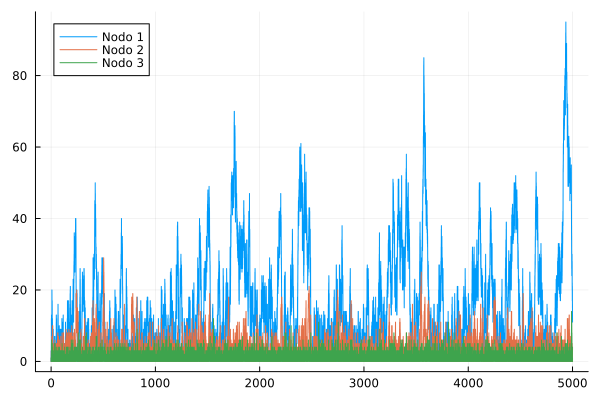

In [29]:
ν = [7.5, 0.0, 0.0]
μ     = [8.0, 6.0, 10.0]
R     = [0.0  0.6  0.4
         0.0  0.0  0.3
         0.0  0.0  0.0]

res = analizar_red_jackson(ν, μ, R, output=false);
T,N = simular_jackson(ν, μ, R, 5000);

n1 = [n[1] for n in N]
n2 = [n[2] for n in N]
n3 = [n[3] for n in N]

plot(T,n1, label="Nodo 1")
plot!(T,n2, label="Nodo 2")
plot!(T,n3, label="Nodo 3")

In [30]:
function ocupacion_media(T,n)
    return sum(n[1:end-1].*diff(T))/T[end]
end

println("Ocupacion empírica: n1=$(ocupacion_media(T,n1)) -- n2=$(ocupacion_media(T,n2)) -- n3=$(ocupacion_media(T,n3))")
println("Ocupacion teorica: n1=$(res.X[1]) -- n2=$(res.X[2]) -- n3=$(res.X[3])")

Ocupacion empírica: n1=14.966860642357055 -- n2=2.984253388155664 -- n3=0.7623611538265181
Ocupacion teorica: n1=15.0 -- n2=3.0 -- n3=0.7699115044247786


## Resumen

| Concepto | Resultado |
|---|---|
| Ecuaciones de tráfico | $(I - R^T)\boldsymbol{\lambda} = \boldsymbol{\nu}$ |
| Teorema de Jackson | $\pi(\mathbf{n}) = \prod_j (1-\rho_j)\rho_j^{n_j}$ |
| Independencia en estado estacionario | Los nodos son M/M/1 independientes con tasas $\lambda_j$ |

**Hipótesis del teorema:**
- Llegadas externas Poisson, independientes entre nodos.
- Tiempos de servicio exponenciales, independientes entre sí y de las llegadas.
- Ruteo Markoviano independiente (probabilidades $r_{ij}$ fijas).
- $\rho_j < 1$ en cada nodo.
- Disciplina FCFS en cada nodo (también vale para PS y LCFS-PR).

**Generalización.** El resultado se extiende a nodos con múltiples servidores M/M/$c_j$, con la distribución marginal de cada nodo siendo la de una cola M/M/$c_j$ con tasa $\lambda_j$. Las ecuaciones de tráfico son idénticas; solo cambian las fórmulas de performance por nodo.